In [ ]:
import sys
from pathlib import Path
import datetime as dt
import numpy as np 
import pandas as pd
import json
import joblib
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor, ExtraTreesRegressor
from sklearn.feature_selection import SelectFromModel, SequentialFeatureSelector
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, median_absolute_error
from sklearn.model_selection import KFold, cross_val_score,  train_test_split, GridSearchCV
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant


In [ ]:
PROJPATH = Path().resolve().parent
sys.path.append((PROJPATH / 'scripts').as_posix())
import riverice_util as ru

ML_LOC = PROJPATH / "data/ML_2025_Nenana"
yrmax = 2024

#### Let's start with Nenana (or another location)

In [ ]:
location = "Tanana River at Nenana"
df = pd.read_csv(ML_LOC / f"DF/DF_{location.replace(' ', '_')}", index_col=0)
df.rename(columns={'t2m': 't2m_M', 'ssr': 'ssr_M', 'sd': 'sd_M'}, inplace=True)
df.drop(columns=['SOI_DJ', 'SOI_FM',], inplace=True)
Xy = df.loc[1980:yrmax, :].dropna()
# Xy.reset_index(inplace=True, names='year')
X = Xy.iloc[:, :-1]
y = Xy.iloc[:, -1]
X_2025 = df.iloc[-1, :-1]
# X_2024 = df.reset_index(names='year').iloc[-1, :-1]

#### Feature selection

In [ ]:
X.columns

Index(['AO_DJ', 'AO_FM', 'EP-NP_DJ', 'EP-NP_FM', 'PNA_DJ', 'PNA_FM',
       'Nino1+2_DJ', 'Nino1+2_FM', 'Nino3_DJ', 'Nino3_FM', 'Nino3.4_DJ',
       'Nino3.4_FM', 'Nino4_DJ', 'Nino4_FM', 'ONI_DJ', 'ONI_FM', 'PDO_DJ',
       'PDO_FM', 'NAO_DJ', 'NAO_FM', 'EA_DJ', 'EA_FM', 'WP_DJ', 'WP_FM',
       'EA-WR_DJ', 'EA-WR_FM', 'SCA_DJ', 'SCA_FM', 'POL_DJ', 'POL_FM',
       'Bering_anomaly_F', 'icethick_Nenana'],
      dtype='object')

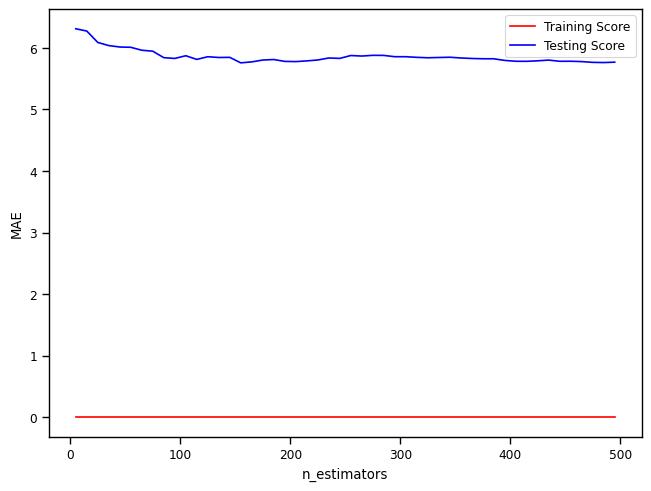

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

numtreeslist = np.arange(5, 500, 10)
train_results = []
test_results = []
for ntrees in numtreeslist:
    clf = ExtraTreesRegressor(n_estimators=ntrees, random_state=41)
    clf = clf.fit(X_train, y_train)
    train_results.append(mean_absolute_error(y_train, clf.predict(X_train)))
    test_results.append(mean_absolute_error(y_test, clf.predict(X_test)))

line1, = plt.plot(numtreeslist, train_results, color="r", label="Training Score")
line2, = plt.plot(numtreeslist, test_results, color="b", label="Testing Score")

plt.legend()
plt.ylabel('MAE')
plt.xlabel('n_estimators')
plt.show()

In [ ]:
clf = ExtraTreesRegressor(n_estimators=100, random_state=42)
clf = clf.fit(X, y)
clf.feature_importances_
selector = SelectFromModel(clf, prefit=True, max_features=12)
X_new = X[X.columns[selector.get_support()]]
X_new

,AO_DJ,AO_FM,EP-NP_FM,Nino3.4_DJ,Nino4_FM,NAO_FM,EA_FM,EA-WR_DJ,SCA_FM,POL_DJ,Bering_anomaly_F,icethick_Nenana
1980,-0.385,-1.183,0.505,0.530,0.275,-0.560,0.025,-0.430,1.045,-0.675,0.10,39.546
1981,-0.087,-0.989,0.000,-0.155,-0.170,-0.525,0.315,-0.755,-0.140,0.990,0.04,39.546
1982,-1.050,1.024,0.785,-0.035,-0.055,0.830,-0.275,0.160,0.725,-0.035,-0.12,39.546
1983,1.163,-1.187,-0.455,2.275,0.280,-0.225,-0.705,0.165,-0.025,-1.035,0.07,39.546
1984,0.545,-1.345,-0.215,-0.850,-0.785,-0.210,-0.620,-1.000,1.385,-0.150,0.11,39.546
1985,-1.180,-0.444,-1.540,-1.250,-0.860,-0.595,-0.350,-0.195,0.435,-1.405,-0.21,39.546
1986,-1.258,-0.486,0.450,-0.535,-0.195,-0.095,-0.130,0.155,1.045,-0.020,-0.05,39.546
1987,-0.544,-1.610,0.120,1.130,0.485,-0.765,-0.375,1.020,0.255,-0.545,0.01,39.546
1988,-0.135,-0.632,0.065,0.920,0.295,-0.080,-0.215,-0.170,0.545,0.730,-0.04,39.546
1989,2.393,2.405,1.470,-1.965,-1.345,1.680,-0.200,0.605,-0.880,0.165,-0.18,42.000


In [ ]:
%timeit
clf = ExtraTreesRegressor(n_estimators=100, random_state=40)
sfs_forward = SequentialFeatureSelector(
    clf, n_features_to_select=4, direction="forward"
).fit(X, y)

In [ ]:
%timeit
clf = ExtraTreesRegressor(n_estimators=100, random_state=40)
sfs_backward = SequentialFeatureSelector(
    clf, n_features_to_select=4, direction="backward"
).fit(X, y)

In [ ]:
X[sfs_forward.get_feature_names_out()].corrwith(y)

Nino3.4_FM   -0.327557
EA_FM        -0.262765
EA-WR_DJ      0.106070
SCA_FM        0.215430
dtype: float64

In [ ]:
X[sfs_backward.get_feature_names_out()].corrwith(y)

Nino4_FM          -0.379467
EA_FM             -0.262765
EA-WR_DJ           0.106070
icethick_Nenana    0.346789
dtype: float64

In [ ]:
X.corr()

,AO_DJ,AO_FM,EP-NP_DJ,EP-NP_FM,PNA_DJ,PNA_FM,SOI_DJ,SOI_FM,Nino1+2_DJ,Nino1+2_FM,...,WP_DJ,WP_FM,EA-WR_DJ,EA-WR_FM,SCA_DJ,SCA_FM,POL_DJ,POL_FM,Bering_anomaly_F,icethick_Nenana
AO_DJ,1.000000,0.309160,-0.301077,0.120708,-0.274443,0.099108,-0.163952,-0.127632,0.082479,0.098016,...,-0.043222,-0.291090,0.134240,-0.211543,-0.342002,-0.135428,0.070669,0.199547,0.071816,-0.135140
AO_FM,0.309160,1.000000,0.011903,0.178083,-0.292589,-0.560125,0.231519,0.169397,-0.123646,0.051473,...,0.297080,-0.098221,0.188283,0.118591,-0.016510,-0.649250,0.185558,0.233824,-0.140866,-0.166182
EP-NP_DJ,-0.301077,0.011903,1.000000,0.291534,0.060902,-0.071080,-0.202106,-0.216756,0.123322,-0.145548,...,-0.013322,-0.164929,-0.005964,0.048058,-0.090649,0.169736,0.196176,0.139448,-0.304823,-0.135584
EP-NP_FM,0.120708,0.178083,0.291534,1.000000,0.033864,-0.095934,-0.211058,-0.236960,0.164854,0.126668,...,0.112700,-0.201844,0.408038,-0.142450,-0.210189,0.135099,0.290037,0.558089,-0.290171,-0.246227
PNA_DJ,-0.274443,-0.292589,0.060902,0.033864,1.000000,0.340677,-0.412214,-0.429301,0.460571,0.285311,...,0.295087,0.004924,0.121172,-0.010129,-0.103129,0.172787,-0.001396,-0.055892,-0.205377,0.144758
PNA_FM,0.099108,-0.560125,-0.071080,-0.095934,0.340677,1.000000,-0.543761,-0.438702,0.475619,0.343104,...,-0.260089,-0.206199,0.031638,-0.255929,-0.349600,0.332108,-0.011911,-0.060778,0.364276,0.020014
SOI_DJ,-0.163952,0.231519,-0.202106,-0.211058,-0.412214,-0.543761,1.000000,0.824021,-0.691578,-0.479555,...,-0.035791,0.164371,-0.341553,0.136086,0.449746,-0.176971,-0.031477,-0.171540,-0.120484,0.018311
SOI_FM,-0.127632,0.169397,-0.216756,-0.236960,-0.429301,-0.438702,0.824021,1.000000,-0.735884,-0.517807,...,-0.139308,0.049442,-0.239586,0.036202,0.363132,-0.143422,0.031679,-0.196865,-0.077218,0.102703
Nino1+2_DJ,0.082479,-0.123646,0.123322,0.164854,0.460571,0.475619,-0.691578,-0.735884,1.000000,0.746552,...,0.149648,-0.049280,0.173784,-0.028842,-0.478747,0.100970,-0.229768,0.123217,0.083165,-0.000331
Nino1+2_FM,0.098016,0.051473,-0.145548,0.126668,0.285311,0.343104,-0.479555,-0.517807,0.746552,1.000000,...,0.318000,0.060835,0.300747,0.112295,-0.309758,-0.205287,-0.188124,0.141268,0.202227,0.002031


In [ ]:
X_new.corrwith(y)

AO_DJ              -0.256188
AO_FM              -0.286342
EP-NP_FM           -0.089378
Nino3.4_DJ         -0.361338
Nino4_FM           -0.379467
NAO_FM             -0.331983
EA_FM              -0.262765
EA-WR_DJ            0.106070
SCA_FM              0.215430
POL_DJ             -0.028907
Bering_anomaly_F    0.095942
icethick_Nenana     0.346789
dtype: float64

### Let's try a multiple linear regression to assess collinearity

In [ ]:
figure = plt.figure(figsize=(12, 10))
sns.heatmap(X.corr(),cmap='coolwarm', vmin=-1, vmax=1)

<Axes: >

In [ ]:
X_forVIF = add_constant(X)
vif_data = pd.DataFrame()
vif_data['Feature'] = X_forVIF.columns
vif_data['VIF'] = [variance_inflation_factor(X_forVIF.values, i) for i in range(X_forVIF.shape[1])]

In [ ]:
X_new.corrwith(y).sort_values(key=abs, ascending=False)

Nino4_FM           -0.379467
Nino3.4_DJ         -0.361338
icethick_Nenana     0.346789
NAO_FM             -0.331983
AO_FM              -0.286342
EA_FM              -0.262765
AO_DJ              -0.256188
SCA_FM              0.215430
EA-WR_DJ            0.106070
Bering_anomaly_F    0.095942
EP-NP_FM           -0.089378
POL_DJ             -0.028907
dtype: float64

In [ ]:
predictorlist = vif_data.sort_values('VIF', ascending=False)['Feature'].to_list()
predictorlist.remove('const')
predictorlist[1:]

['ONI_DJ',
 'Nino3.4_FM',
 'ONI_FM',
 'Nino3_DJ',
 'Nino3_FM',
 'Nino4_FM',
 'Nino4_DJ',
 'AO_FM',
 'PDO_FM',
 'Nino1+2_DJ',
 'NAO_FM',
 'PDO_DJ',
 'Nino1+2_FM',
 'SCA_FM',
 'PNA_FM',
 'POL_FM',
 'WP_FM',
 'SCA_DJ',
 'PNA_DJ',
 'AO_DJ',
 'icethick_Nenana',
 'EA_DJ',
 'WP_DJ',
 'EA_FM',
 'EP-NP_FM',
 'EA-WR_FM',
 'EP-NP_DJ',
 'Bering_anomaly_F',
 'EA-WR_DJ',
 'NAO_DJ',
 'POL_DJ']

In [ ]:
X_forVIF

,const,AO_DJ,AO_FM,EP-NP_DJ,EP-NP_FM,PNA_DJ,PNA_FM,Nino1+2_DJ,Nino1+2_FM,Nino3_DJ,...,WP_DJ,WP_FM,EA-WR_DJ,EA-WR_FM,SCA_DJ,SCA_FM,POL_DJ,POL_FM,Bering_anomaly_F,icethick_Nenana
1980,1.0,-0.385,-1.183,0.53,0.505,-0.845,0.695,-0.165,-0.215,0.405,...,-2.060,0.295,-0.430,-0.860,-0.535,1.045,-0.675,0.235,0.10,39.546
1981,1.0,-0.087,-0.989,1.02,0.000,0.945,0.740,-0.950,-0.860,-0.350,...,-0.040,0.025,-0.755,-0.115,-0.610,-0.140,0.990,-0.330,0.04,39.546
1982,1.0,-1.050,1.024,1.11,0.785,-1.085,-1.430,-0.220,-1.040,0.075,...,0.725,-0.365,0.160,1.035,-0.525,0.725,-0.035,-0.145,-0.12,39.546
1983,1.0,1.163,-1.187,-0.31,-0.455,0.660,1.735,2.905,2.130,2.930,...,-0.425,-1.015,0.165,0.220,-1.600,-0.025,-1.035,0.030,0.07,39.546
1984,1.0,0.545,-1.345,-0.97,-0.215,-0.005,0.905,-0.090,-0.875,-0.710,...,-0.535,-0.685,-1.000,-1.960,1.190,1.385,-0.150,0.740,0.11,39.546
1985,1.0,-1.180,-0.444,1.00,-1.540,-0.230,-1.090,-0.590,-1.135,-1.265,...,-0.785,0.345,-0.195,0.280,0.235,0.435,-1.405,-0.120,-0.21,39.546
1986,1.0,-1.258,-0.486,0.52,0.450,0.840,0.460,-0.190,-0.415,-0.765,...,-0.265,-1.565,0.155,0.640,0.325,1.045,-0.020,1.535,-0.05,39.546
1987,1.0,-0.544,-1.610,-0.74,0.120,0.845,0.710,0.795,1.205,0.970,...,1.660,0.295,1.020,0.225,-0.600,0.255,-0.545,0.205,0.01,39.546
1988,1.0,-0.135,-0.632,1.13,0.065,0.265,0.875,0.345,-0.560,0.840,...,0.580,0.415,-0.170,-1.835,-0.630,0.545,0.730,-0.090,-0.04,39.546
1989,1.0,2.393,2.405,-1.81,1.470,-0.620,-1.635,-0.525,-0.105,-1.525,...,-0.360,-0.725,0.605,-0.255,-0.945,-0.880,0.165,0.790,-0.18,42.000


In [ ]:
thresh = 5

while True:
    if vif_data.loc[vif_data['Feature']!='const'].VIF.max() < thresh:
        break      # second largest VIF value, the largest being the constant usually ... I think
    predictorlist = vif_data.sort_values('VIF', ascending=False)['Feature'].to_list()
    X_forVIF.drop(columns=[predictorlist[0]], inplace=True)
    vif_data = pd.DataFrame()
    vif_data['Feature'] = X_forVIF.columns
    vif_data['VIF'] = [variance_inflation_factor(X_forVIF.values, i) for i in range(X_forVIF.shape[1])]

In [ ]:
vif_data

,Feature,VIF
0,AO_DJ,3.305326
1,EP-NP_DJ,2.778491
2,EP-NP_FM,2.437065
3,PNA_DJ,2.282456
4,PNA_FM,3.977669
5,Nino1+2_FM,2.339228
6,Nino4_DJ,3.556335
7,PDO_DJ,3.072220
8,NAO_DJ,2.028905
9,NAO_FM,2.740407


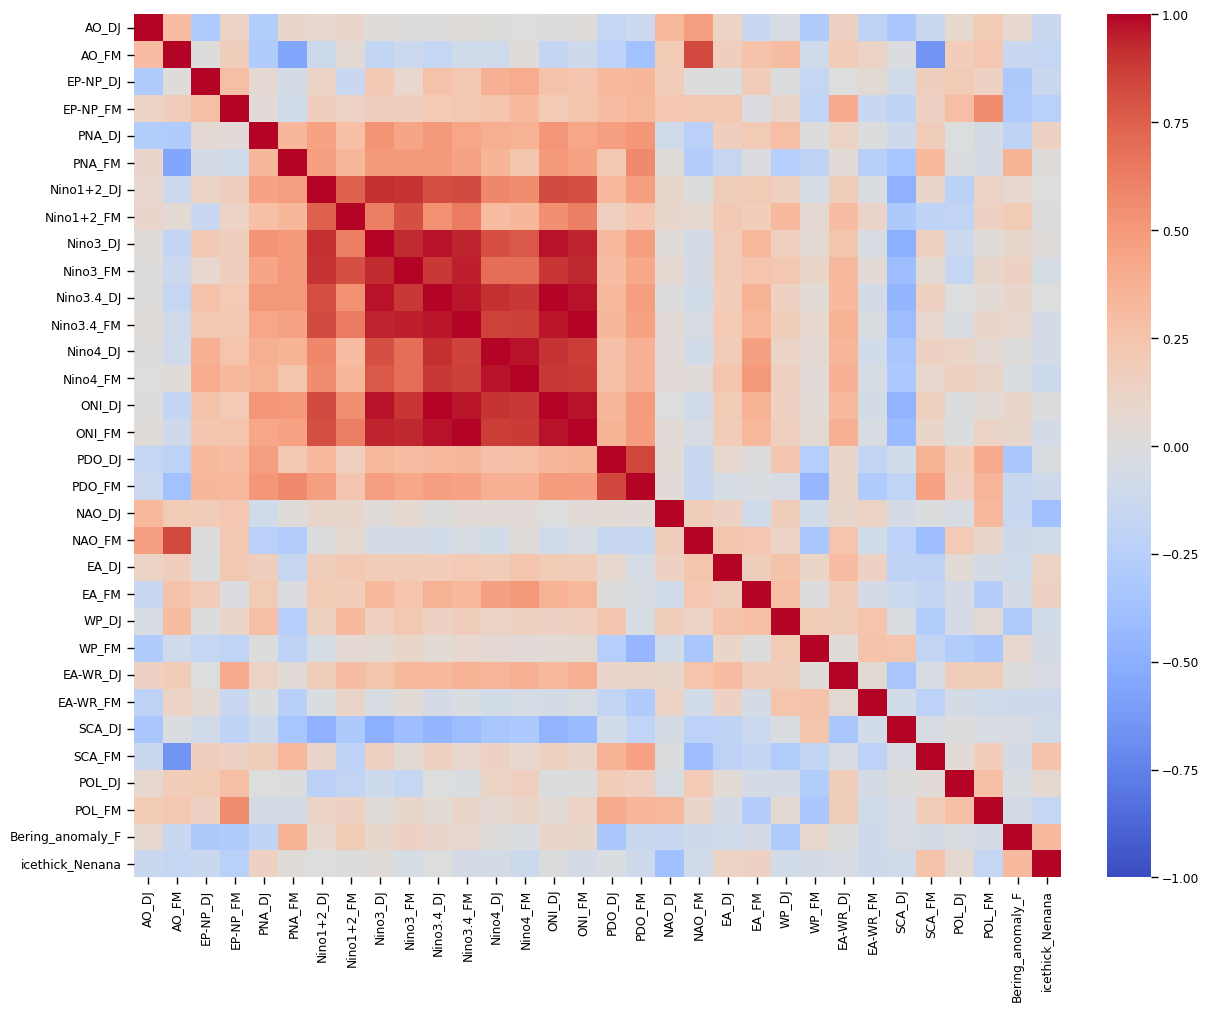

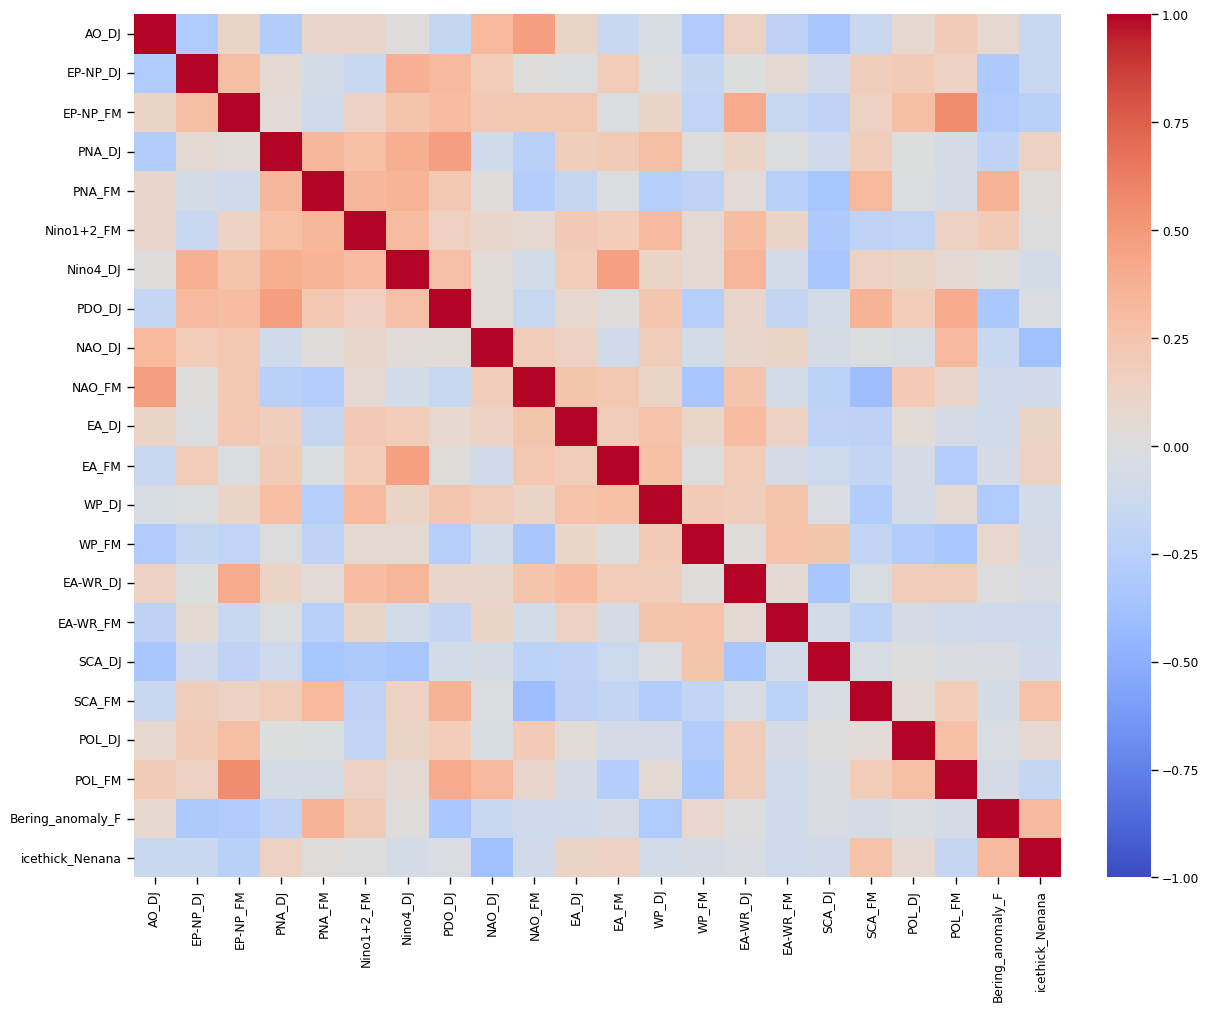

In [ ]:
figure = plt.figure(figsize=(12, 10))
sns.heatmap(X[vif_data.Feature].corr(),cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

In [ ]:
X_VIF = X[vif_data.Feature]

In [ ]:
clf = ExtraTreesRegressor(n_estimators=100, random_state=42)
clf = clf.fit(X_VIF, y)
clf.feature_importances_
selector = SelectFromModel(clf, prefit=True, max_features=15)
X_new = X_VIF[X_VIF.columns[selector.get_support()]]
X_new

,AO_DJ,Nino4_DJ,NAO_FM,EA_FM,EA-WR_DJ,POL_DJ,Bering_anomaly_F,icethick_Nenana
1980,-0.385,0.330,-0.560,0.025,-0.430,-0.675,0.10,39.546
1981,-0.087,-0.080,-0.525,0.315,-0.755,0.990,0.04,39.546
1982,-1.050,-0.060,0.830,-0.275,0.160,-0.035,-0.12,39.546
1983,1.163,0.450,-0.225,-0.705,0.165,-1.035,0.07,39.546
1984,0.545,-0.830,-0.210,-0.620,-1.000,-0.150,0.11,39.546
1985,-1.180,-0.795,-0.595,-0.350,-0.195,-1.405,-0.21,39.546
1986,-1.258,-0.245,-0.095,-0.130,0.155,-0.020,-0.05,39.546
1987,-0.544,0.310,-0.765,-0.375,1.020,-0.545,0.01,39.546
1988,-0.135,0.705,-0.080,-0.215,-0.170,0.730,-0.04,39.546
1989,2.393,-1.745,1.680,-0.200,0.605,0.165,-0.18,42.000


In [ ]:
clf = ExtraTreesRegressor(n_estimators=100, random_state=40)
sfs_forward = SequentialFeatureSelector(
    clf, n_features_to_select=8, direction="forward"
).fit(X_VIF, y)

In [ ]:
X[sfs_forward.get_feature_names_out()].corrwith(y)

AO_DJ             -0.256188
EP-NP_DJ          -0.108460
Nino4_DJ          -0.357788
EA_FM             -0.262765
EA-WR_DJ           0.106070
SCA_FM             0.215430
POL_DJ            -0.028907
icethick_Nenana    0.346789
dtype: float64

In [ ]:
X_new.corrwith(y).sort_values(key=abs, ascending=False)

Nino4_DJ           -0.357788
icethick_Nenana     0.346789
NAO_FM             -0.331983
EA_FM              -0.262765
AO_DJ              -0.256188
EA-WR_DJ            0.106070
Bering_anomaly_F    0.095942
POL_DJ             -0.028907
dtype: float64

Straight CV

In [ ]:
X_new = X[sfs_forward.get_feature_names_out()]

In [ ]:
saveplots = True
summary = {}
summary['location'] = location
summary['predictors'] = list(X_new.columns)

In [ ]:
X_new

,AO_DJ,EP-NP_DJ,Nino4_DJ,EA_FM,EA-WR_DJ,SCA_FM,POL_DJ,icethick_Nenana
1980,-0.385,0.53,0.330,0.025,-0.430,1.045,-0.675,39.546
1981,-0.087,1.02,-0.080,0.315,-0.755,-0.140,0.990,39.546
1982,-1.050,1.11,-0.060,-0.275,0.160,0.725,-0.035,39.546
1983,1.163,-0.31,0.450,-0.705,0.165,-0.025,-1.035,39.546
1984,0.545,-0.97,-0.830,-0.620,-1.000,1.385,-0.150,39.546
1985,-1.180,1.00,-0.795,-0.350,-0.195,0.435,-1.405,39.546
1986,-1.258,0.52,-0.245,-0.130,0.155,1.045,-0.020,39.546
1987,-0.544,-0.74,0.310,-0.375,1.020,0.255,-0.545,39.546
1988,-0.135,1.13,0.705,-0.215,-0.170,0.545,0.730,39.546
1989,2.393,-1.81,-1.745,-0.200,0.605,-0.880,0.165,42.000


In [ ]:
# load model 
modeldir = ML_LOC / 'models'
filename = f"{location.replace(' ', '_')}_joblib_model.sav"
best_model = joblib.load(modeldir / filename)


FileNotFoundError: [Errno 2] No such file or directory: '/Users/christine/Projects/2023_Riverice/data/ML_2024_redux/models/Tanana_River_at_Nenana_joblib_model.sav'

... or calculate it 

In [ ]:
cv_inner = KFold(n_splits=5, shuffle=True, random_state=43)
model = GradientBoostingRegressor(random_state=40)
    # define search space
space = {
        # 'min_samples_leaf': list(range(4, 7)),
        'min_samples_leaf': [3],
        'max_depth': [2],
        'min_samples_split': [3],
        # 'max_depth': [3],
        'n_estimators': [100],  # , 1000, 2000, 5000],
        'learning_rate': np.arange(0.01, 0.02, 0.001),   # 0.006, 0.005], # 0.001, 0.0005, 0.0001],
        'subsample': np.arange(0.4, 0.75, 0.05),
    }
# define search
search = GridSearchCV(model, space, cv=cv_inner, scoring='neg_mean_squared_error', verbose=1, 
            refit=True, n_jobs=6)
# execute search
grid_result = search.fit(X, y)
# get the best performing model fit on the whole training set
best_model = grid_result.best_estimator_
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print(f"{mean}, {stdev}, {param}")

Fitting 5 folds for each of 70 candidates, totalling 350 fits
-38.47670721013869, 24.8798451629771, {'learning_rate': np.float64(0.01), 'max_depth': 2, 'min_samples_leaf': 3, 'min_samples_split': 3, 'n_estimators': 100, 'subsample': np.float64(0.4)}
-37.848608353972686, 23.77370699385596, {'learning_rate': np.float64(0.01), 'max_depth': 2, 'min_samples_leaf': 3, 'min_samples_split': 3, 'n_estimators': 100, 'subsample': np.float64(0.45)}
-38.44972552995472, 25.463605403961783, {'learning_rate': np.float64(0.01), 'max_depth': 2, 'min_samples_leaf': 3, 'min_samples_split': 3, 'n_estimators': 100, 'subsample': np.float64(0.5)}
-38.58233034201724, 25.41533814211766, {'learning_rate': np.float64(0.01), 'max_depth': 2, 'min_samples_leaf': 3, 'min_samples_split': 3, 'n_estimators': 100, 'subsample': np.float64(0.55)}
-37.55283185248775, 24.41519359615697, {'learning_rate': np.float64(0.01), 'max_depth': 2, 'min_samples_leaf': 3, 'min_samples_split': 3, 'n_estimators': 100, 'subsample': np.floa

In [ ]:
grid_result.cv_results_['mean_test_score'][grid_result.best_index_]

np.float64(-35.96492397256485)

In [ ]:
best_model.get_params()

{'alpha': 0.9,
 'ccp_alpha': 0.0,
 'criterion': 'friedman_mse',
 'init': None,
 'learning_rate': np.float64(0.016999999999999994),
 'loss': 'squared_error',
 'max_depth': 2,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 3,
 'min_samples_split': 3,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_iter_no_change': None,
 'random_state': 40,
 'subsample': np.float64(0.7),
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}

In [ ]:
summary['modelparams'] = best_model.get_params()
summary['rms_cv'] = np.sqrt(-grid_result.cv_results_['mean_test_score'][grid_result.best_index_])
summary['rms_std_cv'] = np.sqrt(grid_result.cv_results_['std_test_score'][grid_result.best_index_])

The mean absolute error (MAbsE) on train set: 2.7278
The mean absolute error (MAbsE) on test set: 2.6249
The score for this training set is 0.7250
The validation score for this test set is 0.4300
Pearson score on training set: 0.9281
Pearson score on test set: 0.6753



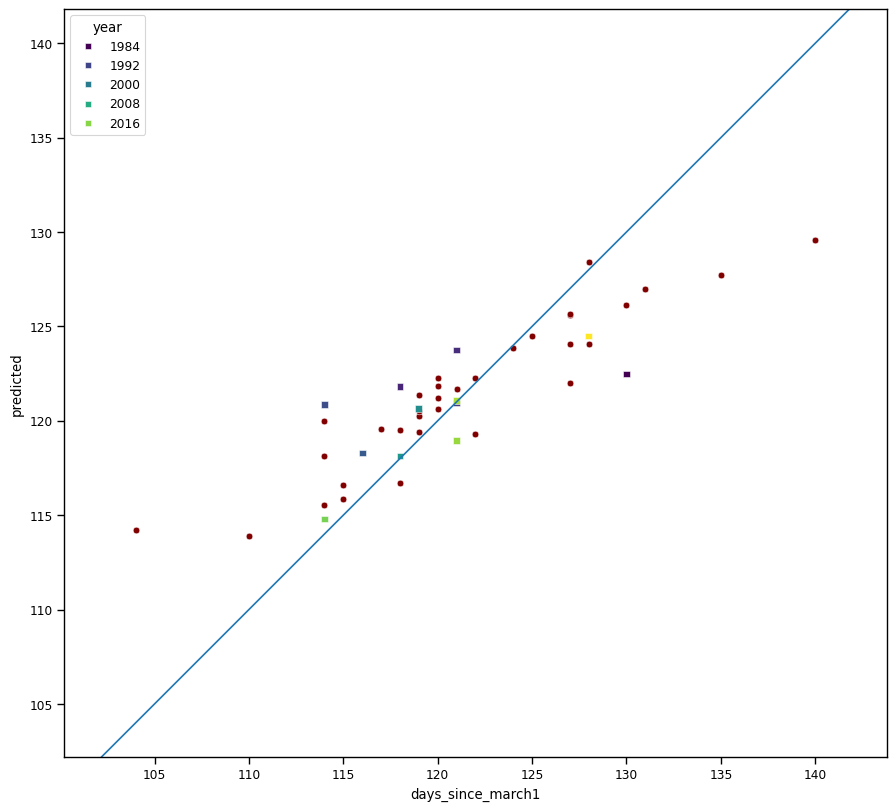

In [ ]:
random_seed = 2021
X_train, X_test, y_train, y_test = train_test_split(
    X_new, y, test_size=0.25, random_state=random_seed)

params_gb = {
        'min_samples_leaf': 3,
        'min_samples_split': 3,
        'max_depth': 2,
        # 'n_estimators': [250, 200, 150, 100],
        'n_estimators': 50,
        'learning_rate': 0.08,
        'subsample': 0.65,
    'random_state': random_seed, 
}
model1 = GradientBoostingRegressor(**params_gb)
model2 = RandomForestRegressor(random_state=random_seed)
model2 = best_model
model3 = ExtraTreesRegressor(n_estimators=200)
model3 = RandomForestRegressor(random_state=random_seed)
# define search
model = VotingRegressor(estimators=[('gb', model1), ('rf', model2), ('lr', model3)])
model = model2
# execute search
result = model.fit(X_train, y_train)
# get the best performing model fit on the whole training set
mse = mean_absolute_error(y_train, model.predict(X_train))
print("The mean absolute error (MAbsE) on train set: {:.4f}".format(mse))
mse = mean_absolute_error(y_test, model.predict(X_test))
print("The mean absolute error (MAbsE) on test set: {:.4f}".format(mse))
print(f"The score for this training set is {model.score(X_train, y_train):.4f}")
print(f"The validation score for this test set is {model.score(X_test, y_test):.4f}")
print(f"Pearson score on training set: {np.corrcoef(y_train.values, model.predict(X_train))[1, 0]:.4f}")
print(f"Pearson score on test set: {np.corrcoef(y_test.values, model.predict(X_test))[1, 0]:.4f}")
pred = model.predict(X_test)
print()

plot_df = pd.DataFrame(y_test)
plot_df.reset_index(inplace=True)
plot_df.columns = ['year', 'days_since_march1']
plot_df['predicted'] = model.predict(X_test)
plot_df_train = pd.DataFrame(y_train)
plot_df_train.reset_index(inplace=True)
plot_df_train.columns = ['year', 'days_since_march1']
plot_df_train['predicted'] = model.predict(X_train)
fig, ax = plt.subplots(1, 1, figsize=(12,8), sharex=True)

sns.scatterplot(x='days_since_march1', y='predicted', data=plot_df_train, color='maroon', ax=ax)
sns.scatterplot(x='days_since_march1', y='predicted', data=plot_df, hue='year', marker='s', palette='viridis', ax=ax)
lims = ax.get_xlim()
ax.set_ylim(lims)
ax.axline([ax.get_xlim()[0], ax.get_ylim()[0]], [ax.get_xlim()[1], ax.get_ylim()[1]])
ax.set_aspect('equal')
plt.show(fig)
if saveplots:
    outdir = ML_LOC / "overfitting_tests"
    fn = f"{location.replace(' ', '_')}_overfit.png"
    fig.savefig(outdir / fn, bbox_inches='tight')

The mean absolute error (MAbsE) on train set: 2.5016 days
The mean absolute error (MAbsE) on test set: 3.8779 days
The score for this training set is 0.6957
The validation score for this test set is 0.1873
Pearson score on training set: 0.9190
Pearson score on test set: 0.5495



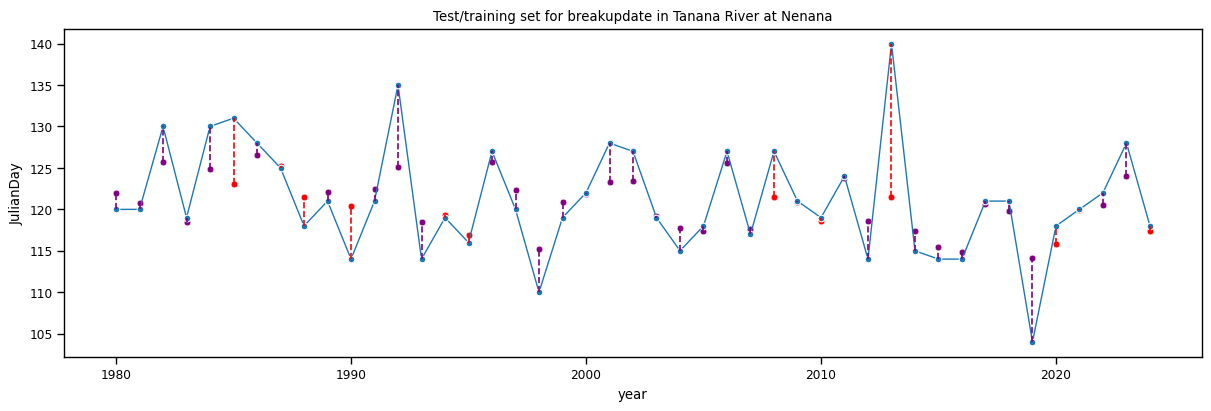

In [ ]:
var = 'JulianDay'

X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.25, random_state=41)
model = best_model
# model = model1

model.fit(X_train, y_train)
mse = mean_absolute_error(y_train, model.predict(X_train))
print("The mean absolute error (MAbsE) on train set: {:.4f} days".format(mse))
mse = mean_absolute_error(y_test, model.predict(X_test))
print("The mean absolute error (MAbsE) on test set: {:.4f} days".format(mse))
print(f"The score for this training set is {model.score(X_train, y_train):.4f}")
print(f"The validation score for this test set is {model.score(X_test, y_test):.4f}")
print(f"Pearson score on training set: {np.corrcoef(y_train.values, model.predict(X_train))[1, 0]:.4f}")
print(f"Pearson score on test set: {np.corrcoef(y_test.values, model.predict(X_test))[1, 0]:.4f}")
pred = best_model.predict(X_test)
print()

plot_df = pd.DataFrame(y_test)
plot_df.reset_index(inplace=True)
plot_df.columns = ['year', var]
plot_df['predicted_test'] = model.predict(X_test) 
plot_df_train = pd.DataFrame(y_train)
plot_df_train.reset_index(inplace=True)
plot_df_train.columns = ['year', var]
plot_df_train['predicted_train'] = model.predict(X_train) 
plot_df = pd.concat([plot_df, plot_df_train]).sort_values(by='year')
plot_df[f'{var}'] = plot_df[f'{var}']


fig, ax = plt.subplots(figsize=(12, 4))

# observed data
sns.lineplot(x='year', y=var, data=plot_df, ax=ax, marker="o", lw=1)
# training data 
# for vertical lines
aux1 = plot_df[['year', f'{var}', 'predicted_train']].dropna()
aux1['min'] = aux1[[f'{var}', 'predicted_train']].min(axis=1)
aux1['max'] = aux1[[f'{var}', 'predicted_train']].max(axis=1)
for _, item in aux1.iterrows():
    plt.vlines(item['year'], item['min'], item['max'], color='purple', linestyles='dashed')
sns.scatterplot(x='year', y='predicted_train', data=aux1, color='purple', ax=ax)

# test data
# for vertical lines
aux1 = plot_df[['year', f'{var}', 'predicted_test']].dropna()
aux1['min'] = aux1[[f'{var}', 'predicted_test']].min(axis=1)
aux1['max'] = aux1[[f'{var}', 'predicted_test']].max(axis=1)
for _, item in aux1.iterrows():
    plt.vlines(item['year'], item['min'], item['max'], color='red', linestyles='dashed')
sns.scatterplot(x='year', y='predicted_test', data=aux1, color='red', ax=ax)
plt.title(f"Test/training set for breakupdate in {location}")

plt.show(fig)

In [ ]:
var = 'JulianDay'

testsizes = np.arange(0.01, 0.90, 0.01)
test_errors = []
training_errors = []
for testsize in testsizes:
    training_store = []
    for ii in range(10):
        X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=testsize, random_state=random_seed+ii)
        model = best_model
        model.fit(X_train, y_train)
        training_store.append(mean_absolute_error(y_test, model.predict(X_test)))
    training_errors.append(mean_absolute_error(y_train, model.predict(X_train)))
    test_errors.append(sum(training_store)/10)



KeyboardInterrupt: 

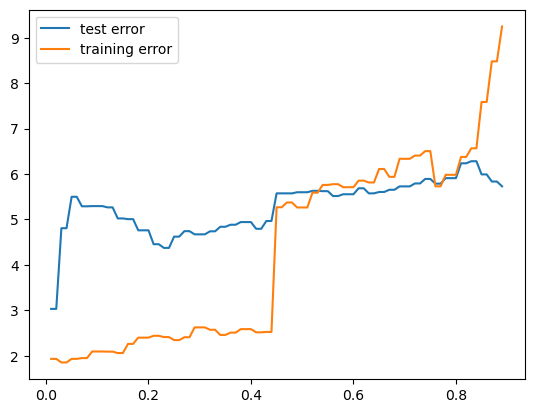

In [ ]:
fig, ax = plt.subplots()

plt.plot(testsizes, test_errors, label='test error')
plt.plot(testsizes, training_errors, label='training error')
plt.legend()

With cross-validation

In [ ]:
cross_val_score(model, X_new, y, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

array([-31.35761583, -50.77072591, -26.78868908, -50.54906126,
       -30.66164908])

In [ ]:
y.std()

np.float64(6.681801003207492)

In [ ]:
model.score(X_train, y_train)

0.6956575961223126

In [ ]:
model.score(X_test, y_test)

0.18727356005707496

/var/folders/39/6h0p929579n8vrp25cjkbz3h0000gn/T/ipykernel_54852/1715048033.py:14: UserWarning: The figure layout has changed to tight
  ax.figure.tight_layout()


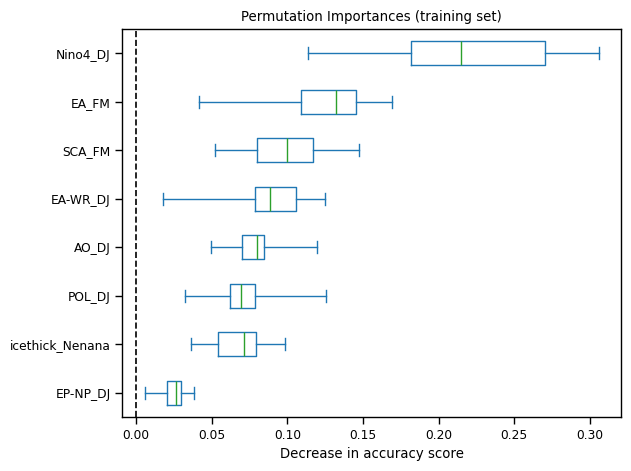

In [ ]:
result = permutation_importance(
    model, X_train, y_train, n_repeats=20, random_state=42, n_jobs=2
)

sorted_importances_idx = result.importances_mean.argsort()
importances = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=X_new.columns[sorted_importances_idx],
)
ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Permutation Importances (training set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()
if saveplots:
    outdir = ML_LOC / "importances"
    fn = f"{location.replace(' ', '_')}_permutation_imp_train.png"
    plt.savefig(outdir / fn, bbox_inches='tight')
plt.show()

/var/folders/39/6h0p929579n8vrp25cjkbz3h0000gn/T/ipykernel_54852/1573464195.py:14: UserWarning: The figure layout has changed to tight
  ax.figure.tight_layout()


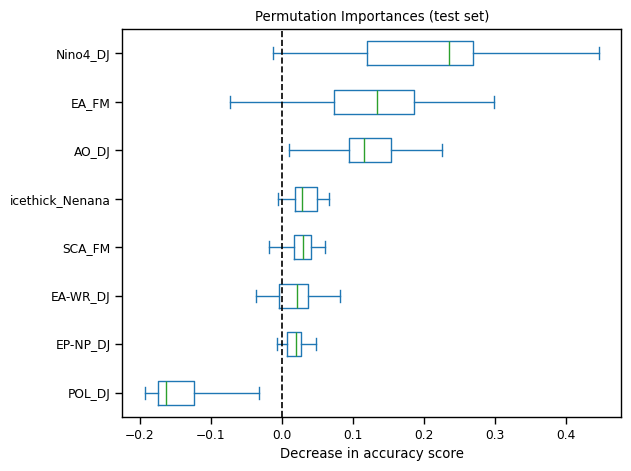

In [ ]:
result = permutation_importance(
    model, X_test, y_test, n_repeats=20, random_state=42, n_jobs=2
)

sorted_importances_idx = result.importances_mean.argsort()
importances = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=X_new.columns[sorted_importances_idx],
)
ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Permutation Importances (test set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()
if saveplots:
    outdir = ML_LOC / "importances"
    fn = f"{location.replace(' ', '_')}_permutation_imp_test.png"
    plt.savefig(outdir / fn, bbox_inches='tight')
plt.show()


In [ ]:
importances.columns[-12:]

Index(['POL_DJ', 'EP-NP_DJ', 'EA-WR_DJ', 'SCA_FM', 'icethick_Nenana', 'AO_DJ',
       'EA_FM', 'Nino4_DJ'],
      dtype='object')

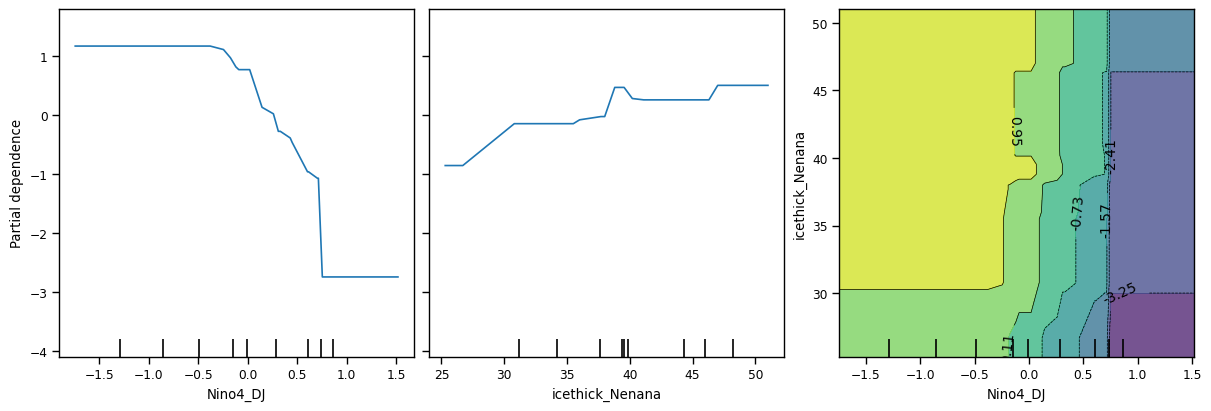

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
sns.set_context('paper')
plt.rcParams['figure.constrained_layout.use'] = True

figure, ax = plt.subplots(figsize=(12, 4))

clf = model.fit(X_train, y_train)
PartialDependenceDisplay.from_estimator(clf, X_new, 
    ['Nino4_DJ', 'icethick_Nenana', ('Nino4_DJ', 'icethick_Nenana')],
    ax=ax)
plt.show()

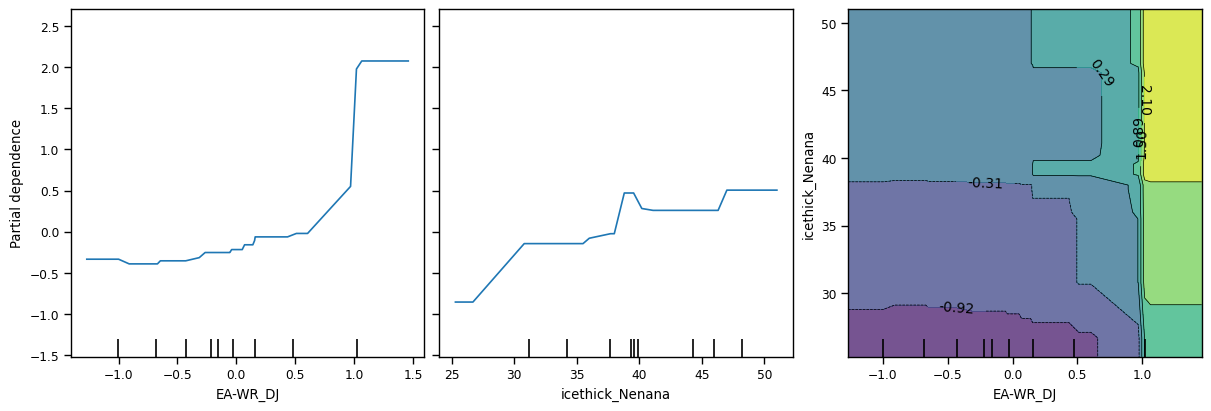

In [ ]:
figure, ax = plt.subplots(figsize=(12, 4))
PartialDependenceDisplay.from_estimator(clf, X_new, 
    ['EA-WR_DJ', 'icethick_Nenana', ('EA-WR_DJ', 'icethick_Nenana')],
    ax=ax)
plt.show()

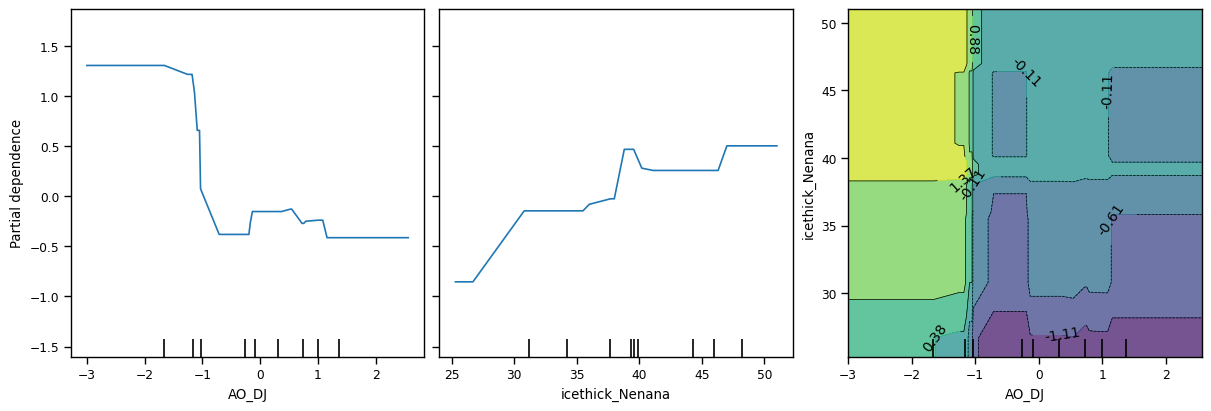

In [ ]:
figure, ax = plt.subplots(figsize=(12, 4))
PartialDependenceDisplay.from_estimator(clf, X_new, 
    ['AO_DJ', 'icethick_Nenana', ('AO_DJ', 'icethick_Nenana')],
    ax=ax)
plt.show()

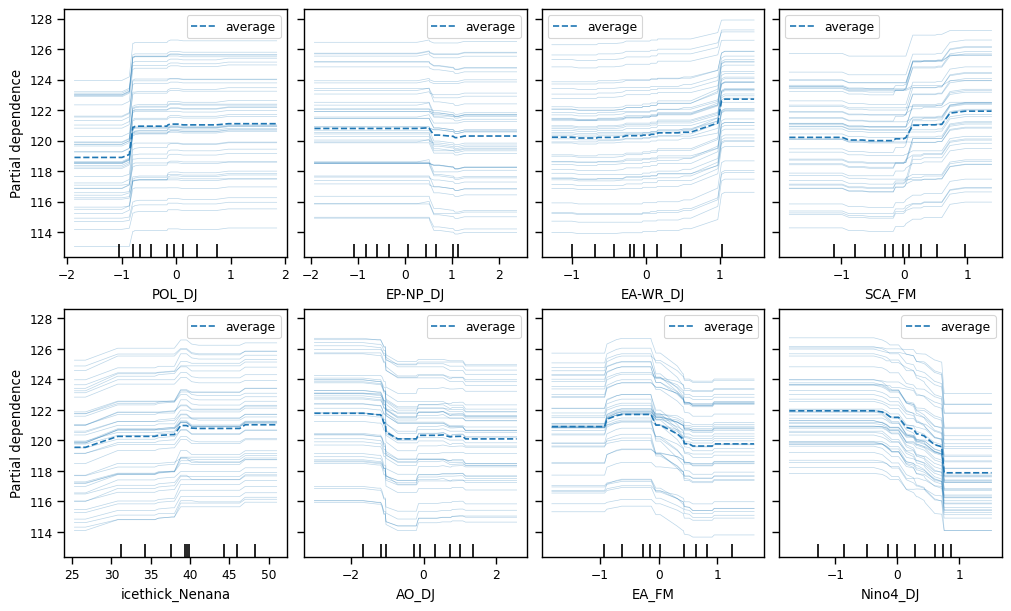

In [ ]:
figure, ax = plt.subplots(figsize=(10, 6))

clf = model.fit(X_train, y_train)
PartialDependenceDisplay.from_estimator(clf, X_new, importances.columns[-12:],
    kind='both', ax=ax, n_cols=4)
plt.show()

In [ ]:
X_new

,AO_DJ,EP-NP_DJ,EP-NP_FM,PNA_DJ,PNA_FM,SOI_FM,Nino1+2_FM,Nino4_DJ,PDO_DJ,NAO_DJ,...,WP_DJ,WP_FM,EA-WR_DJ,EA-WR_FM,SCA_DJ,SCA_FM,POL_DJ,POL_FM,Bering_anomaly_F,icethick_Nenana
1980,-0.385,0.53,0.505,-0.845,0.695,-0.10,-0.215,0.330,0.060,-0.375,...,-2.060,0.295,-0.430,-0.860,-0.535,1.045,-0.675,0.235,0.10,39.546
1981,-0.087,1.02,0.000,0.945,0.740,-1.20,-0.860,-0.080,0.740,-0.095,...,-0.040,0.025,-0.755,-0.115,-0.610,-0.140,0.990,-0.330,0.04,39.546
1982,-1.050,1.11,0.785,-1.085,-1.430,0.70,-1.040,-0.060,0.350,0.005,...,0.725,-0.365,0.160,1.035,-0.525,0.725,-0.035,-0.145,-0.12,39.546
1983,1.163,-0.31,-0.455,0.660,1.735,-5.00,2.130,0.450,0.280,0.760,...,-0.425,-1.015,0.165,0.220,-1.600,-0.025,-1.035,0.030,0.07,39.546
1984,0.545,-0.97,-0.215,-0.005,0.905,0.50,-0.875,-0.830,1.570,0.665,...,-0.535,-0.685,-1.000,-1.960,1.190,1.385,-0.150,0.740,0.11,39.546
1985,-1.180,1.00,-1.540,-0.230,-1.090,1.65,-1.135,-0.795,0.675,-1.135,...,-0.785,0.345,-0.195,0.280,0.235,0.435,-1.405,-0.120,-0.21,39.546
1986,-1.258,0.52,0.450,0.840,0.460,-0.45,-0.415,-0.245,0.685,0.805,...,-0.265,-1.565,0.155,0.640,0.325,1.045,-0.020,1.535,-0.05,39.546
1987,-0.544,-0.74,0.120,0.845,0.710,-2.10,1.205,0.310,1.590,-0.820,...,1.660,0.295,1.020,0.225,-0.600,0.255,-0.545,0.205,0.01,39.546
1988,-0.135,1.13,0.065,0.265,0.875,0.25,-0.560,0.705,0.585,0.580,...,0.580,0.415,-0.170,-1.835,-0.630,0.545,0.730,-0.090,-0.04,39.546
1989,2.393,-1.81,1.470,-0.620,-1.635,1.90,-0.105,-1.745,-0.690,-0.150,...,-0.360,-0.725,0.605,-0.255,-0.945,-0.880,0.165,0.790,-0.18,42.000


In [ ]:
model.fit(X_new, y)

GradientBoostingRegressor(learning_rate=np.float64(0.016999999999999994),
                          max_depth=2, min_samples_leaf=3, min_samples_split=3,
                          random_state=40, subsample=np.float64(0.7))

In [ ]:
X_2025

AO_DJ               -0.203
AO_FM               -0.154
EP-NP_DJ            -0.350
EP-NP_FM             0.625
PNA_DJ               1.045
PNA_FM               0.600
Nino1+2_DJ          -0.175
Nino1+2_FM           0.840
Nino3_DJ            -0.340
Nino3_FM             0.240
Nino3.4_DJ          -0.670
Nino3.4_FM          -0.220
Nino4_DJ            -0.425
Nino4_FM            -0.470
ONI_DJ              -0.555
ONI_FM              -0.390
PDO_DJ              -1.655
PDO_FM              -1.265
NAO_DJ              -1.120
NAO_FM               0.635
EA_DJ                2.700
EA_FM                0.730
WP_DJ                1.020
WP_FM                0.545
EA-WR_DJ            -1.340
EA-WR_FM             0.205
SCA_DJ              -0.720
SCA_FM               0.600
POL_DJ               0.210
POL_FM              -1.460
Bering_anomaly_F    -0.210
icethick_Nenana     32.000
Name: 2025, dtype: float64

In [ ]:
best_model.fit(X_new, y)
prediction = best_model.predict(pd.DataFrame(X_2025[sfs_forward.get_feature_names_out()]).T)
since_date = dt.datetime.strptime('20250101', "%Y%m%d")
preddate = (since_date + dt.timedelta(days=prediction.item())).date().strftime("%Y-%m-%d")

# summary['prediction_2024'] = prediction.item()
# summary['pred_date_2024'] = preddate

# 

prediction, preddate


# ru.dayssince2date(prediction.item())

(array([121.0988486]), '2025-05-02')

### Shaply analysis

In [ ]:
import shap

In [ ]:
X_sample = shap.utils.sample(X_new, 50)

In [ ]:
X_test

,AO_DJ,EP-NP_DJ,Nino4_DJ,EA_FM,EA-WR_DJ,SCA_FM,POL_DJ,icethick_Nenana
1994,-0.196,2.38,0.145,0.765,0.070,0.265,0.440,51.000
2024,-0.216,0.08,1.520,1.625,0.280,0.135,-0.760,49.000
1990,0.178,-0.58,0.020,1.430,-0.225,-1.825,-0.645,36.000
1995,0.370,1.03,0.820,-0.715,-0.210,-1.200,0.695,34.000
1987,-0.544,-0.74,0.310,-0.375,1.020,0.255,-0.545,39.546
2013,-1.179,0.12,-0.010,-0.050,0.050,0.215,-1.345,49.300
1988,-0.135,1.13,0.705,-0.215,-0.170,0.545,0.730,39.546
2010,-3.000,-0.58,1.150,1.240,-1.270,0.320,0.325,46.300
1985,-1.180,1.00,-0.795,-0.350,-0.195,0.435,-1.405,39.546
2020,1.415,-0.60,0.860,0.635,-0.225,-1.785,0.125,34.500


In [ ]:
explainer = shap.Explainer(best_model.predict, X_new)
shap_values = explainer(pd.DataFrame(X_2025[sfs_forward.get_feature_names_out()]).T)
shap_values_all = explainer(X_new)
explainer2 = shap.Explainer(best_model.predict, X_test)
shap_values_test = explainer2(X_test)
sample_ind = 20

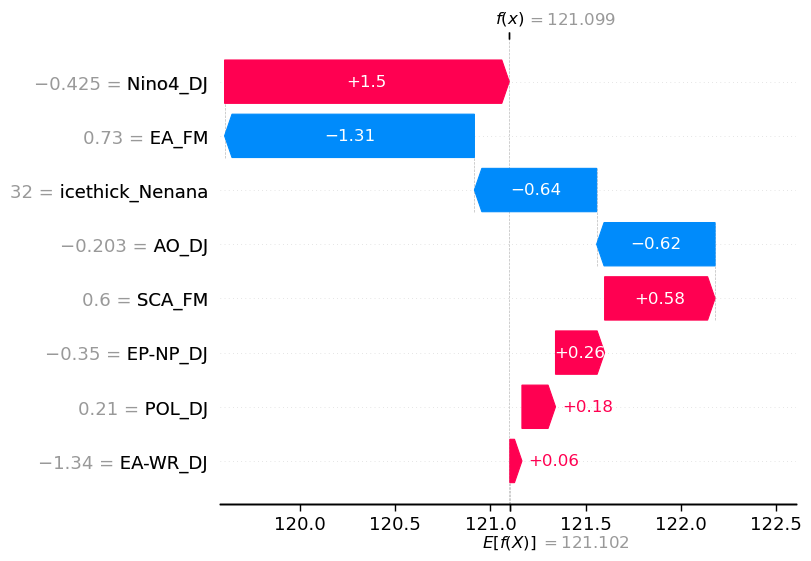

In [ ]:
ax = shap.plots.waterfall(shap_values[0], max_display=12, show=False)
# ax.set_title(f"2024, {location}")
if saveplots:
    outdir = ML_LOC / "importances"
    fn = f"{location.replace(' ', '_')}_shap_waterfall_2024.png"
    plt.savefig(outdir / fn, bbox_inches='tight')
plt.show()

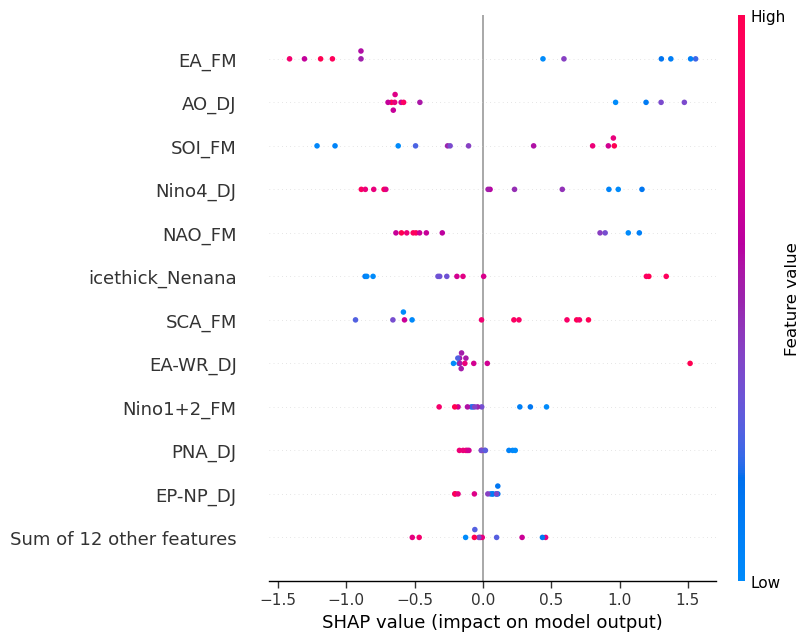

In [ ]:
shap.plots.beeswarm(shap_values_test, max_display=12)

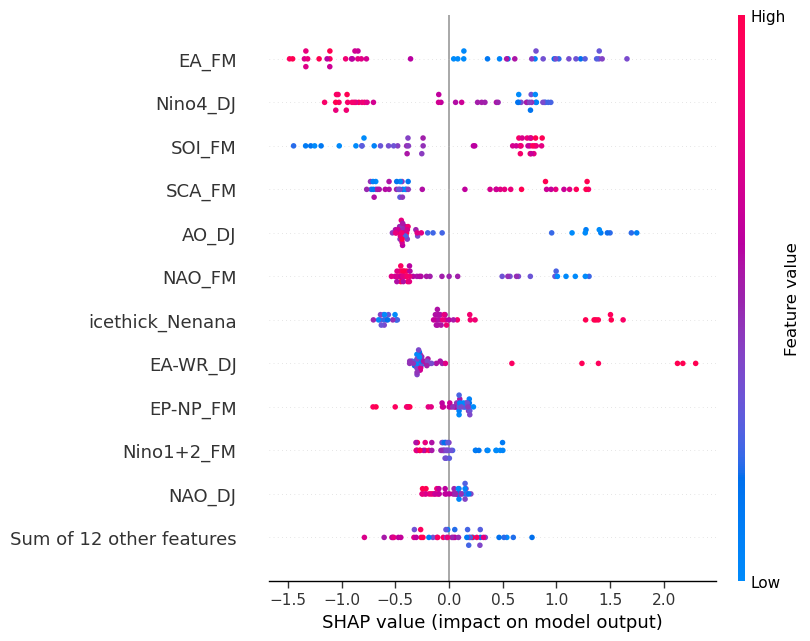

In [ ]:
shap.plots.beeswarm(shap_values_all, max_display=12, show=False)

if saveplots:
    outdir = ML_LOC / "importances"
    fn = f"{location.replace(' ', '_')}_shap_beehive.png"
    plt.savefig(outdir / fn, bbox_inches='tight')
plt.show()


In [ ]:
if saveplots:

    modeldir = ML_LOC / 'models'
    filename = f"{location.replace(' ', '_')}_joblib_model.sav"
    joblib.dump(model, modeldir / filename)
    summarydir =ML_LOC / 'model_eval'
    summaryfn = f"{location.replace(' ', '_')}_modelsummary.json"
    with open(summarydir / summaryfn, 'w' ) as dst: 
        json.dump(summary, dst, indent=2)
